# 01 — PA-4: os fluxos origem→destino são estáveis ao longo do ano?

**Story:** US-07 · **Pergunta analítica 4 (PA-4):** os grandes fluxos de internação
origem→destino se repetem mês a mês, ou mudam conforme o mês?

**Por que isso importa para o decisor (Secretaria Estadual de Saúde da PB):** se os
*mesmos* pares origem→destino dominam **todos** os meses do ano, o fluxo é
**estrutural** — quer dizer, é um padrão fixo da rede de saúde, e por isso dá para
planejar em cima dele (pactuar vagas, dimensionar leitos, desenhar a PPI — a
Programação Pactuada e Integrada, o instrumento em que os municípios combinam quem
atende quem). Se, ao contrário, os fluxos oscilassem muito de mês para mês, o
fenômeno seria **conjuntural** (algo pontual, tipo um serviço fora do ar por um
período) e exigiria outro tipo de política, mais reativa.

**Entrada:** `data/processed/matriz_od_municipal_mensal.parquet` — a matriz
origem→destino construída na US-04 (15.054 linhas, 258.125 internações de 2025).

**Saídas:**

| Arquivo | Conteúdo |
|---|---|
| `outputs/tables/pa4_top_pares_od.csv` | os 20 maiores pares origem→destino do ano + em quantos meses cada um ficou no top 20 |
| `outputs/tables/pa4_permanencia_mensal.csv` | mês a mês: quantos dos 20 pares anuais aparecem no top 20 do mês |
| `outputs/figures/pa4_estabilidade_fluxo.png` | a visualização do achado |

Nada aqui depende de internet: tudo é lido de arquivos já congelados no repositório.

## 1. Carregando a matriz origem→destino

A matriz da US-04 está no formato "longo": **uma linha por (par origem→destino × mês)**.
As colunas que vamos usar:

- `mes` — mês de competência (1 a 12);
- `cod_mun_res` / `nome_mun_res` / `uf_res` — código IBGE, nome e estado do município
  onde o paciente **mora** (origem);
- `cod_mun_int` / `nome_mun_int` — código e nome do município onde ele foi **internado**
  (destino);
- `internacoes` — quantas internações naquele par, naquele mês;
- `evasao_municipal` — `True` quando origem ≠ destino, ou seja, o paciente se internou
  **fora** do município onde mora. É essa a definição operacional de "evasão" no projeto.

Guardamos o total geral (258.125) numa variável para servir de **soma de controle**: em
toda agregação seguinte vamos conferir que nenhuma internação sumiu no caminho.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Caminhos relativos à raiz do projeto (mesmo padrão dos outros notebooks 01-*)
if Path.cwd().name == "notebooks":
    os.chdir("..")

matriz = pd.read_parquet("data/processed/matriz_od_municipal_mensal.parquet")

TOTAL_BASE = int(matriz["internacoes"].sum())
print(f"Linhas da matriz (par O-D x mes): {len(matriz):,}".replace(",", "."))
print(f"Internacoes representadas:        {TOTAL_BASE:,}".replace(",", "."))
print(f"Meses presentes: {sorted(matriz['mes'].unique())}")
matriz.head(3)

Linhas da matriz (par O-D x mes): 15.054
Internacoes representadas:        258.125
Meses presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,mes,cod_mun_res,nome_mun_res,uf_res,regiao_res,cod_mun_int,nome_mun_int,regiao_int,internacoes,evasao_municipal
0,1,110020,Porto Velho,RO,Fora da PB,250750,João Pessoa,1ª Região Mata Atlântica - PB,1,True
1,1,140010,Boa Vista,RR,Fora da PB,250750,João Pessoa,1ª Região Mata Atlântica - PB,1,True
2,1,150210,Cametá,PA,Fora da PB,250750,João Pessoa,1ª Região Mata Atlântica - PB,1,True


## 2. Recorte da análise: só os fluxos de evasão

A PA-4 pergunta sobre **fluxos**, e um "fluxo" só existe quando o paciente sai do seu
município para se internar em outro. Internações dentro do próprio município
(`evasao_municipal == False`) não são fluxo nenhum — são a rede local funcionando —, então
ficam de fora deste recorte.

**Uma decisão técnica que muda números (e vale entender):** vamos identificar cada par
origem→destino pelo **código IBGE** dos dois municípios, não pelo nome. Motivo: nomes de
município se repetem entre estados. Existe uma Santa Rita na Paraíba (código 251370) e
outra no Maranhão (211020); existe um Conde na PB (250460) e outro na Bahia (290860). Se
agrupássemos por nome, misturaríamos moradores de estados diferentes no mesmo "par".

Isso gera uma **diferença pequena e esperada** em relação ao número citado no notebook
da US-04 (que agrupou por nome): lá, Santa Rita → João Pessoa aparece com 5.645
internações; aqui aparece com 5.638, porque as 7 restantes são de moradores de Santa
Rita **do Maranhão**. Conferimos essa decomposição na próxima seção — não é erro de
conta, é um critério mais rigoroso. O ranking dos maiores pares não muda.

In [2]:
fluxos = matriz[matriz["evasao_municipal"]].copy()

# Chave do par O-D pelos códigos IBGE (nomes podem repetir entre UFs)
fluxos["par"] = fluxos["cod_mun_res"] + ">" + fluxos["cod_mun_int"]

TOTAL_EVASAO = int(fluxos["internacoes"].sum())
print(f"Internacoes fora do municipio de residencia: {TOTAL_EVASAO:,}".replace(",", "."))
print(f"= {100 * TOTAL_EVASAO / TOTAL_BASE:.1f}% do total da base")
print(f"Pares origem->destino distintos no ano: {fluxos['par'].nunique():,}".replace(",", "."))

Internacoes fora do municipio de residencia: 130.379
= 50.5% do total da base
Pares origem->destino distintos no ano: 2.802


### 2.1 Validação (a): nenhuma internação perdida na separação

Separar a base em "dentro do município" e "fora do município" não pode criar nem sumir
com internação nenhuma. O `assert` abaixo é um teste automático: se a conta não fechar,
o notebook para com erro em vez de seguir com número errado.

In [3]:
dentro = int(matriz.loc[~matriz["evasao_municipal"], "internacoes"].sum())
print(f"Fora do municipio:   {TOTAL_EVASAO:,}".replace(",", "."))
print(f"Dentro do municipio: {dentro:,}".replace(",", "."))
print(f"Soma:                {TOTAL_EVASAO + dentro:,}".replace(",", "."))
assert TOTAL_EVASAO + dentro == TOTAL_BASE, "O recorte perdeu/criou internacoes!"
print("OK - validacao (a): fora + dentro = total da base (258.125).")

Fora do municipio:   130.379
Dentro do municipio: 127.746
Soma:                258.125
OK - validacao (a): fora + dentro = total da base (258.125).


## 3. Os 20 maiores pares origem→destino do ano

Somamos as internações de cada par ao longo dos 12 meses e ordenamos do maior para o
menor. Também calculamos a **participação de cada par no total de internações fora do
município** — assim dá para dizer não só "esse é o maior fluxo", mas "esse fluxo sozinho
representa X% de toda a evasão do estado".

**Validação (b):** a soma das internações de *todos* os pares (não só do top 20) precisa
ser exatamente igual ao total de evasão calculado na seção anterior.

**Conferência contra o já apurado na US-04:** o maior par do ano deve ser
Santa Rita → João Pessoa e o segundo, Bayeux → João Pessoa (4.307). E Santa Rita/PB
(5.638) + Santa Rita/MA (7) tem que dar os 5.645 do agrupamento por nome.

In [4]:
# Rótulo fixo de cada par (o nome não muda ao longo do ano; pegamos a primeira ocorrência)
rotulos = fluxos.drop_duplicates("par").set_index("par")[
    ["nome_mun_res", "uf_res", "nome_mun_int"]
]

anual = (
    fluxos.groupby("par", observed=True)["internacoes"]
    .sum()
    .sort_values(ascending=False)
)

# Validação (b): soma dos pares = total de evasão
assert int(anual.sum()) == TOTAL_EVASAO, "Agregacao anual por par perdeu internacoes!"
print(
    f"OK - validacao (b): soma dos {len(anual)} pares = "
    + f"{int(anual.sum()):,}".replace(",", ".")
    + " = total de evasao."
)

top20 = anual.head(20)
PARES_TOP20 = list(top20.index)

tabela_top20 = top20.rename("internacoes_ano").reset_index().join(
    rotulos.loc[PARES_TOP20].reset_index(drop=True)
)
tabela_top20.insert(0, "posicao", range(1, 21))
tabela_top20["pct_da_evasao"] = (100 * tabela_top20["internacoes_ano"] / TOTAL_EVASAO).round(2)

print(
    f"Os 20 maiores pares somam {int(top20.sum()):,}".replace(",", ".")
    + f" internacoes = {100 * top20.sum() / TOTAL_EVASAO:.1f}% de toda a evasao do ano."
)
tabela_top20[["posicao", "nome_mun_res", "uf_res", "nome_mun_int", "internacoes_ano", "pct_da_evasao"]]

OK - validacao (b): soma dos 2802 pares = 130.379 = total de evasao.
Os 20 maiores pares somam 32.179 internacoes = 24.7% de toda a evasao do ano.


,posicao,nome_mun_res,uf_res,nome_mun_int,internacoes_ano,pct_da_evasao
0,1,Santa Rita,PB,João Pessoa,5638,4.32
1,2,Bayeux,PB,João Pessoa,4307,3.30
2,3,Cabedelo,PB,João Pessoa,2151,1.65
3,4,Sapé,PB,João Pessoa,1910,1.46
4,5,Conde,PB,João Pessoa,1714,1.31
5,6,Queimadas,PB,Campina Grande,1629,1.25
6,7,João Pessoa,PB,Santa Rita,1461,1.12
7,8,Lagoa Seca,PB,Campina Grande,1357,1.04
8,9,Guarabira,PB,João Pessoa,1338,1.03
9,10,Mamanguape,PB,João Pessoa,1248,0.96


In [5]:
# Conferência contra os números da US-04 (que agrupou por NOME de município)
santa_rita_pb = int(anual["251370>250750"])
por_nome = int(
    fluxos[(fluxos["nome_mun_res"] == "Santa Rita") & (fluxos["nome_mun_int"] == "João Pessoa")][
        "internacoes"
    ].sum()
)
bayeux = int(anual["250180>250750"])

print(f"Santa Rita/PB -> Joao Pessoa (por codigo IBGE): {santa_rita_pb:,}".replace(",", "."))
print(f"Santa Rita (qualquer UF) -> Joao Pessoa (por nome): {por_nome:,}".replace(",", "."))
print(f"Diferenca (moradores de Santa Rita/MA): {por_nome - santa_rita_pb}")
print(f"Bayeux -> Joao Pessoa: {bayeux:,}".replace(",", "."))

assert por_nome == 5645, "Sanity check do maior par (por nome) divergiu do apurado na US-04!"
assert bayeux == 4307, "Sanity check do 2o maior par divergiu do apurado na US-04!"
assert tabela_top20.loc[0, "nome_mun_res"] == "Santa Rita"
assert tabela_top20.loc[1, "nome_mun_res"] == "Bayeux"
print("OK - sanity check: os dois maiores pares do ano reproduzem os numeros da US-04.")

Santa Rita/PB -> Joao Pessoa (por codigo IBGE): 5.638
Santa Rita (qualquer UF) -> Joao Pessoa (por nome): 5.645
Diferenca (moradores de Santa Rita/MA): 7
Bayeux -> Joao Pessoa: 4.307
OK - sanity check: os dois maiores pares do ano reproduzem os numeros da US-04.


In [6]:
# Conferencia contra os numeros do caso Conde, citado no resumo da secao 9
# (mesma logica do sanity check de Santa Rita/Bayeux acima: Conde e homonimo
# entre PB (250460) e BA (290860) - por isso precisa ser resolvido por codigo IBGE)
conde_pb = int(anual.get("250460>250750", 0))
conde_ba = int(anual.get("290860>250750", 0))
conde_por_nome = int(
    fluxos[(fluxos["nome_mun_res"] == "Conde") & (fluxos["nome_mun_int"] == "João Pessoa")][
        "internacoes"
    ].sum()
)

print(f"Conde/PB -> Joao Pessoa (por codigo IBGE): {conde_pb:,}".replace(",", "."))
print(f"Conde/BA -> Joao Pessoa (por codigo IBGE): {conde_ba:,}".replace(",", "."))
print(f"Conde (qualquer UF) -> Joao Pessoa (por nome): {conde_por_nome:,}".replace(",", "."))

assert conde_pb + conde_ba == conde_por_nome, "Conde/PB + Conde/BA nao bate com o total por nome!"
print("OK - sanity check: Conde/PB + Conde/BA = Conde por nome, como citado na secao 9.")


Conde/PB -> Joao Pessoa (por codigo IBGE): 1.714
Conde/BA -> Joao Pessoa (por codigo IBGE): 1
Conde (qualquer UF) -> Joao Pessoa (por nome): 1.715
OK - sanity check: Conde/PB + Conde/BA = Conde por nome, como citado na secao 9.


## 4. Como medir "estabilidade"? A medida escolhida e por quê

Estabilidade é um conceito vago, então precisamos transformá-lo num número. Olhamos a
pergunta de três formas complementares — as três medem a mesma coisa por ângulos
diferentes, e por isso se reforçam:

**1) Taxa de sobreposição (*overlap*) mês a mês — a medida principal.**
Monta-se o top 20 de *cada mês* e conta-se quantos daqueles 20 pares também estão no
top 20 **do ano**. Se o resultado for 20 de 20 todo mês, os grandes fluxos são
literalmente os mesmos o ano inteiro. Se fosse 5 de 20, o "mapa dos fluxos" se
redesenharia a cada mês.
*Por que essa medida:* é direta, não exige nenhuma suposição estatística e responde
exatamente o que o gestor pergunta — "posso planejar minha rede em cima destes fluxos?".

**2) Em quantos meses cada par anual se mantém no top 20 (de 0 a 12).**
É a mesma informação vista por par, não por mês. Serve para separar o núcleo duro
(pares que aparecem nos 12 meses) dos pares que entram e saem do ranking — tipicamente
os que ficam na fronteira da 20ª posição, onde poucas internações a mais ou a menos já
mudam a ordem.

**3) Correlação de ranking (Spearman) entre o mês e o ano.**
A correlação de Spearman compara **ordens**, não valores: pergunta se os pares que são
grandes no ano também são grandes naquele mês, na mesma sequência. O número vai de -1 a
+1. **Em linguagem leiga:** 1,0 significa "a fila é exatamente a mesma"; 0 significa
"a ordem de um mês não tem nada a ver com a ordem do ano"; valores acima de 0,9
significam "quase a mesma fila, com trocas pequenas entre vizinhos de posição".
Calculamos à mão (transformando os volumes em postos e correlacionando os postos), para
não adicionar dependência de biblioteca nova ao projeto.

Uma ressalva honesta sobre a medida 3: ela é calculada só sobre os 20 pares do ano, para
responder "a ordem *deles* se mantém?". Não é uma correlação sobre todos os pares.

In [7]:
def spearman(a, b):
    # Correlação de Spearman = correlação de Pearson calculada sobre os POSTOS (rankings)
    ra = pd.Series(a).rank()
    rb = pd.Series(b).rank()
    return float(np.corrcoef(ra, rb)[0, 1])


linhas = []
meses_no_top20 = {p: 0 for p in PARES_TOP20}

for mes, g in fluxos.groupby("mes", observed=True):
    do_mes = g.groupby("par", observed=True)["internacoes"].sum().sort_values(ascending=False)
    top20_mes = list(do_mes.head(20).index)

    for p in top20_mes:
        if p in meses_no_top20:
            meses_no_top20[p] += 1

    sobreposicao = len(set(top20_mes) & set(PARES_TOP20))
    linhas.append(
        {
            "mes": int(mes),
            "internacoes_fora_do_municipio": int(g["internacoes"].sum()),
            "pares_top20_mes_tambem_no_top20_ano": sobreposicao,
            "taxa_sobreposicao_pct": round(100 * sobreposicao / 20, 1),
            "spearman_mes_vs_ano": round(
                spearman(top20.values, do_mes.reindex(PARES_TOP20).fillna(0).values), 3
            ),
        }
    )

permanencia = pd.DataFrame(linhas)

# Validação (c): a soma dos 12 meses tem que devolver o total de evasão
assert int(permanencia["internacoes_fora_do_municipio"].sum()) == TOTAL_EVASAO, (
    "A quebra mensal perdeu/criou internacoes!"
)
print(
    "OK - validacao (c): soma dos 12 meses = "
    + f"{TOTAL_EVASAO:,}".replace(",", ".")
    + " = total de evasao do ano."
)
permanencia

OK - validacao (c): soma dos 12 meses = 130.379 = total de evasao do ano.


,mes,internacoes_fora_do_municipio,pares_top20_mes_tambem_no_top20_ano,taxa_sobreposicao_pct,spearman_mes_vs_ano
0,1,9981,17,85.0,0.928
1,2,9870,18,90.0,0.917
2,3,10843,18,90.0,0.920
3,4,10665,18,90.0,0.938
4,5,11145,18,90.0,0.924
5,6,11259,17,85.0,0.933
6,7,11473,16,80.0,0.950
7,8,11885,19,95.0,0.942
8,9,11424,18,90.0,0.917
9,10,11774,16,80.0,0.926


### 4.1 Lendo a tabela acima

Três colunas contam a história:

- **`pares_top20_mes_tambem_no_top20_ano`** — a sobreposição. Quanto mais perto de 20,
  mais os grandes fluxos do mês são os mesmos grandes fluxos do ano.
- **`taxa_sobreposicao_pct`** — a mesma coisa em porcentagem, para citar no texto.
- **`spearman_mes_vs_ano`** — a "fila" dos 20 pares no mês comparada à do ano.

Abaixo, o resumo: média, mínimo e máximo de cada uma.

In [8]:
sob = permanencia["pares_top20_mes_tambem_no_top20_ano"]
print("Sobreposicao com o top 20 do ano (de 20 pares):")
print(f"  media  = {sob.mean():.1f} ({permanencia['taxa_sobreposicao_pct'].mean():.1f}%)")
print(f"  minimo = {sob.min()} (mes {int(permanencia.loc[sob.idxmin(), 'mes'])})")
print(f"  maximo = {sob.max()} (mes {int(permanencia.loc[sob.idxmax(), 'mes'])})")
print()
print("Correlacao de ranking (Spearman) mes x ano:")
print(
    f"  media = {permanencia['spearman_mes_vs_ano'].mean():.3f}"
    f" | minimo = {permanencia['spearman_mes_vs_ano'].min():.3f}"
    f" | maximo = {permanencia['spearman_mes_vs_ano'].max():.3f}"
)

Sobreposicao com o top 20 do ano (de 20 pares):
  media  = 17.1 (85.4%)
  minimo = 14 (mes 12)
  maximo = 19 (mes 8)

Correlacao de ranking (Spearman) mes x ano:
  media = 0.928 | minimo = 0.908 | maximo = 0.950


## 5. Em quantos meses cada um dos 20 pares se manteve no top 20

Agora a visão por par. A coluna `meses_no_top20` vai de 0 a 12. Um par com 12/12 é
**núcleo duro**: esteve entre os 20 maiores fluxos do estado em todos os meses de 2025.

In [9]:
tabela_top20["meses_no_top20"] = tabela_top20["par"].map(meses_no_top20)
tabela_top20["nucleo_duro_12_meses"] = tabela_top20["meses_no_top20"] == 12

n_nucleo = int(tabela_top20["nucleo_duro_12_meses"].sum())
print(f"Pares presentes nos 12 meses: {n_nucleo} de 20")
print(f"Media de meses no top 20: {tabela_top20['meses_no_top20'].mean():.2f}")
print(f"Minimo: {tabela_top20['meses_no_top20'].min()} meses")
print()
print("Volume dos pares 'nucleo duro' (12/12) vs o resto do top 20:")
print(
    tabela_top20.groupby("nucleo_duro_12_meses")["internacoes_ano"]
    .agg(["count", "sum", "mean"])
    .round(0)
)

tabela_top20[
    ["posicao", "nome_mun_res", "nome_mun_int", "internacoes_ano", "pct_da_evasao", "meses_no_top20"]
]

Pares presentes nos 12 meses: 13 de 20
Media de meses no top 20: 10.25
Minimo: 6 meses

Volume dos pares 'nucleo duro' (12/12) vs o resto do top 20:
                      count    sum    mean
nucleo_duro_12_meses                      
False                     7   5935   848.0
True                     13  26244  2019.0


,posicao,nome_mun_res,nome_mun_int,internacoes_ano,pct_da_evasao,meses_no_top20
0,1,Santa Rita,João Pessoa,5638,4.32,12
1,2,Bayeux,João Pessoa,4307,3.30,12
2,3,Cabedelo,João Pessoa,2151,1.65,12
3,4,Sapé,João Pessoa,1910,1.46,12
4,5,Conde,João Pessoa,1714,1.31,12
5,6,Queimadas,Campina Grande,1629,1.25,12
6,7,João Pessoa,Santa Rita,1461,1.12,12
7,8,Lagoa Seca,Campina Grande,1357,1.04,12
8,9,Guarabira,João Pessoa,1338,1.03,12
9,10,Mamanguape,João Pessoa,1248,0.96,12


### 5.1 Por que alguns pares não ficam nos 12 meses?

Repare no padrão: os pares que **não** fecham 12/12 são justamente os do fim da lista
(posições 14 a 20), com volumes anuais próximos entre si — na casa de 790 a 920
internações no ano, ou seja, uns 70 por mês. Quando vários pares têm praticamente o
mesmo tamanho, **uma diferença de três ou quatro internações já troca as posições**. Não
é o fluxo que desaparece: é a fronteira do ranking que é apertada.

Ou seja: a instabilidade que a medida capta está na **borda** do top 20, não no topo. Os
pares grandes — os que de fato importam para planejar rede — não saem do lugar.

## 6. Duas checagens independentes: os polos e a sazonalidade

**(i) A participação dos dois polos.** Se os fluxos são estruturais, a fatia das
internações de não-residentes que vai parar em João Pessoa + Campina Grande deve ser
parecida em todos os meses. É uma checagem independente da anterior: não olha pares
individuais, olha o destino agregado. Se as duas linhas de raciocínio derem a mesma
conclusão, a confiança no achado aumenta.

**(ii) Sazonalidade de volume.** Estabilidade de *composição* (quem vai para onde) é uma
coisa; volume total é outra. Um mês pode ter menos internações no geral e mesmo assim
manter exatamente os mesmos fluxos. Vamos olhar as duas coisas lado a lado — e comentar
apenas o que o dado mostra, sem inventar explicação para o que não dá para verificar com
esta base.

In [10]:
por_destino = (
    fluxos.groupby(["mes", "nome_mun_int"], observed=True)["internacoes"].sum().unstack(fill_value=0)
)
tot_mes = por_destino.sum(axis=1)

polos = pd.DataFrame(
    {
        "mes": tot_mes.index.astype(int),
        "internacoes_fora_do_municipio": tot_mes.values.astype(int),
        "joao_pessoa": por_destino["João Pessoa"].values.astype(int),
        "campina_grande": por_destino["Campina Grande"].values.astype(int),
    }
)
polos["pct_dois_polos"] = (
    100 * (polos["joao_pessoa"] + polos["campina_grande"]) / polos["internacoes_fora_do_municipio"]
).round(1)

pmin, pmax = polos["pct_dois_polos"].min(), polos["pct_dois_polos"].max()
print("Participacao dos 2 polos no total de internacoes de nao-residentes, por mes:")
print(f"  minimo = {pmin:.1f}% (mes {int(polos.loc[polos['pct_dois_polos'].idxmin(), 'mes'])})")
print(f"  maximo = {pmax:.1f}% (mes {int(polos.loc[polos['pct_dois_polos'].idxmax(), 'mes'])})")
print(f"  amplitude = {pmax - pmin:.1f} pontos percentuais")
print()
vol = polos["internacoes_fora_do_municipio"]
print("Volume mensal de internacoes fora do municipio:")
print(f"  menor mes = {vol.min():,}".replace(",", ".") + f" (mes {int(polos.loc[vol.idxmin(), 'mes'])})")
print(f"  maior mes = {vol.max():,}".replace(",", ".") + f" (mes {int(polos.loc[vol.idxmax(), 'mes'])})")

# Sanity check contra o intervalo já apurado (56,6% a 61,3%)
assert abs(pmin - 56.6) < 0.05, "Minimo da participacao dos polos divergiu do esperado!"
assert abs(pmax - 61.3) < 0.05, "Maximo da participacao dos polos divergiu do esperado!"
print()
print("OK - sanity check: participacao dos 2 polos entre 56,6% e 61,3%, como o ja apurado.")
polos

Participacao dos 2 polos no total de internacoes de nao-residentes, por mes:
  minimo = 56.6% (mes 12)
  maximo = 61.3% (mes 1)
  amplitude = 4.7 pontos percentuais

Volume mensal de internacoes fora do municipio:
  menor mes = 9.744 (mes 12)
  maior mes = 11.885 (mes 8)

OK - sanity check: participacao dos 2 polos entre 56,6% e 61,3%, como o ja apurado.


,mes,internacoes_fora_do_municipio,joao_pessoa,campina_grande,pct_dois_polos
0,1,9981,3561,2555,61.3
1,2,9870,3380,2512,59.7
2,3,10843,3362,3017,58.8
3,4,10665,3449,2840,59.0
4,5,11145,3555,2924,58.1
5,6,11259,3601,2849,57.3
6,7,11473,3705,2919,57.7
7,8,11885,3844,3040,57.9
8,9,11424,3934,2967,60.4
9,10,11774,4143,2758,58.6


### 6.1 O que os números da seção 6 dizem

- **Composição estável.** A fatia dos dois polos varia numa faixa estreita ao longo dos
  12 meses. Como esse indicador é calculado de um jeito completamente diferente do
  ranking de pares, ele funciona como confirmação independente: os dois caminhos levam à
  mesma conclusão.
- **Volume varia, composição não.** Os meses de menor volume de internações fora do
  município aparecem no começo e no fim do ano; os maiores, no segundo semestre.
  **Cuidado com a interpretação:** dezembro é a competência mais sujeita a *retificação*
  (o DATASUS ainda recebe correções de registro depois do fechamento do mês), então
  parte da queda do fim do ano pode ser dado ainda incompleto, e não menos internação de
  fato. Não é possível separar as duas coisas com esta base — fica registrado como
  limitação, sem extrapolar.

## 7. A visualização (título-afirmação)

A regra do projeto é que o título do gráfico **afirme o achado**, em vez de só nomear os
eixos ("Top 20 pares"). Quem bate o olho tem que sair sabendo a conclusão.

O gráfico tem dois painéis:

- **À esquerda:** os 20 maiores fluxos do ano, com a marcação de em quantos meses cada
  um esteve entre os 20 maiores. As barras escuras são o núcleo duro (12/12 meses).
- **À direita:** mês a mês, quantos dos 20 maiores fluxos do ano continuam entre os 20
  maiores daquele mês — a linha da estabilidade.

Sem jargão dentro da figura: nada de "O-D", "overlap" ou "Spearman" nos rótulos.

Figura salva: outputs\figures\pa4_estabilidade_fluxo.png (338 KB)


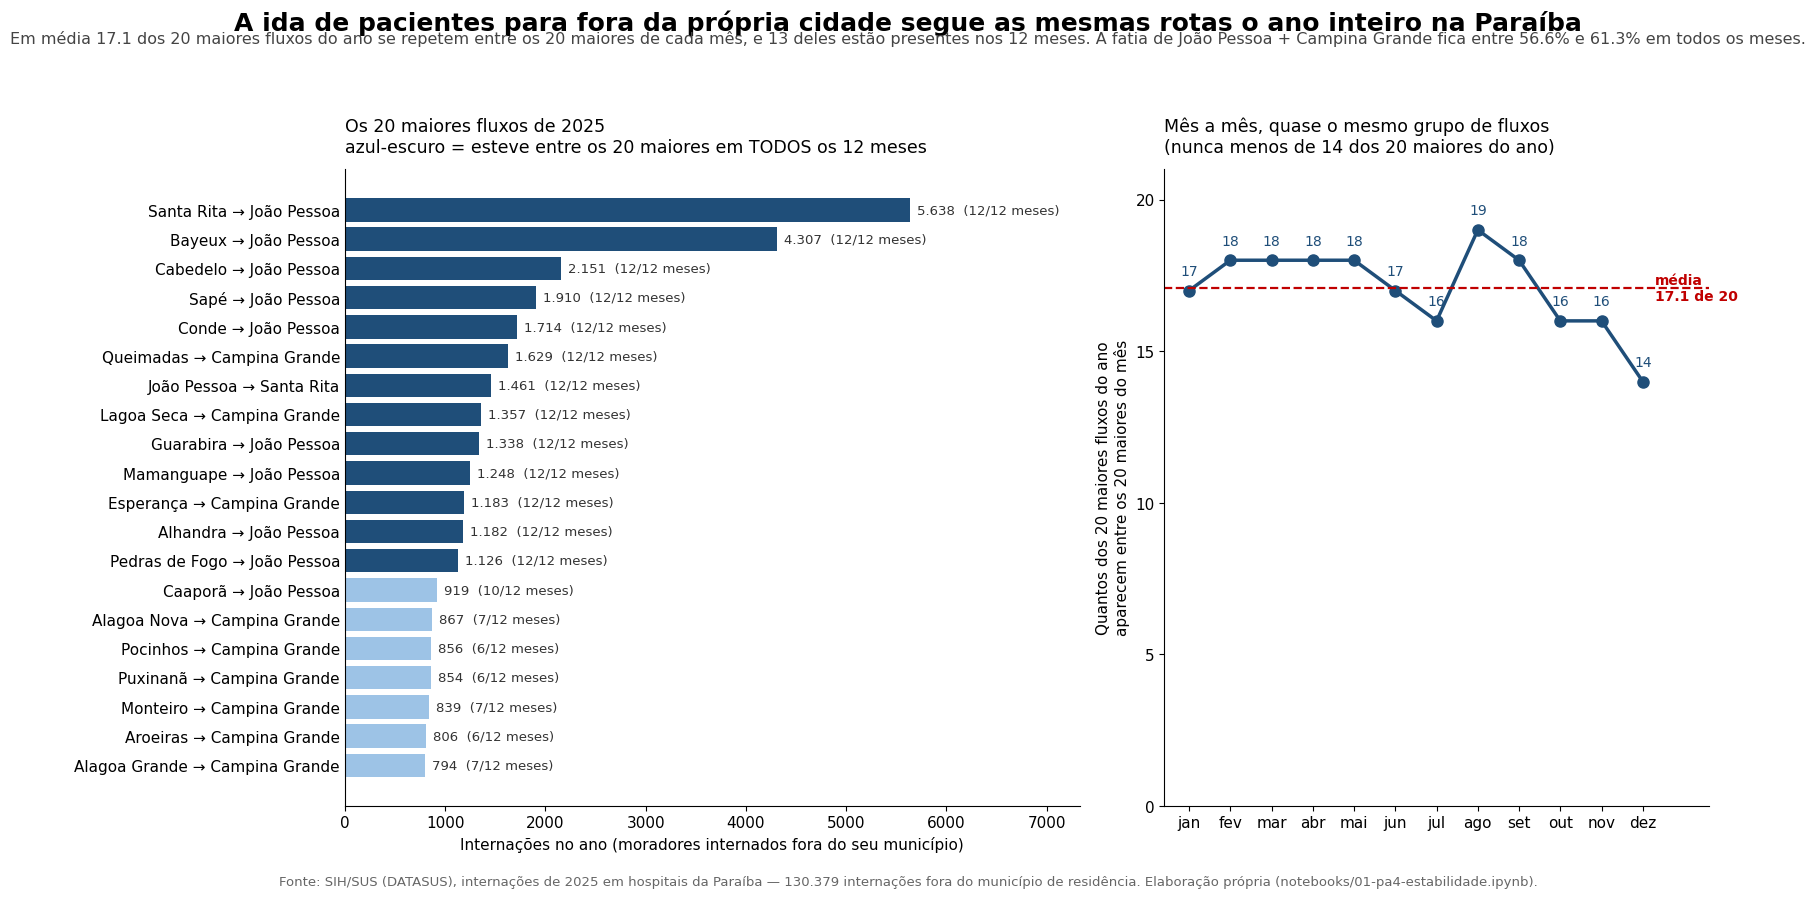

In [11]:
plt.rcParams.update({"font.size": 11, "axes.grid": False})

MESES_ABREV = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
COR_NUCLEO, COR_BORDA = "#1f4e79", "#9dc3e6"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 9), gridspec_kw={"width_ratios": [1.35, 1]})

# ---------- Painel esquerdo: os 20 maiores fluxos do ano ----------
plot = tabela_top20.sort_values("internacoes_ano")
rotulos_y = plot["nome_mun_res"] + " → " + plot["nome_mun_int"]
cores = [COR_NUCLEO if n == 12 else COR_BORDA for n in plot["meses_no_top20"]]

ax1.barh(rotulos_y, plot["internacoes_ano"], color=cores)
for y, (v, n) in enumerate(zip(plot["internacoes_ano"], plot["meses_no_top20"])):
    ax1.text(
        v + 70,
        y,
        f"{v:,}".replace(",", ".") + f"  ({n}/12 meses)",
        va="center",
        fontsize=9.5,
        color="#333333",
    )
ax1.set_xlim(0, plot["internacoes_ano"].max() * 1.30)
ax1.set_xlabel("Internações no ano (moradores internados fora do seu município)")
ax1.set_title(
    "Os 20 maiores fluxos de 2025\n"
    "azul-escuro = esteve entre os 20 maiores em TODOS os 12 meses",
    fontsize=12.5,
    loc="left",
    pad=12,
)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="y", length=0)

# ---------- Painel direito: estabilidade mês a mês ----------
x = permanencia["mes"]
y = permanencia["pares_top20_mes_tambem_no_top20_ano"]
ax2.plot(x, y, marker="o", color=COR_NUCLEO, linewidth=2.5, markersize=8)
ax2.axhline(y.mean(), color="#c00000", linestyle="--", linewidth=1.6)
ax2.text(
    12.3,
    y.mean(),
    f"média\n{y.mean():.1f} de 20",
    color="#c00000",
    va="center",
    fontsize=10,
    fontweight="bold",
)
for xi, yi in zip(x, y):
    ax2.text(xi, yi + 0.5, str(int(yi)), ha="center", fontsize=10, color="#1f4e79")

ax2.set_ylim(0, 21)
ax2.set_xlim(0.4, 13.6)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MESES_ABREV)
ax2.set_yticks([0, 5, 10, 15, 20])
ax2.set_ylabel("Quantos dos 20 maiores fluxos do ano\naparecem entre os 20 maiores do mês")
ax2.set_title(
    f"Mês a mês, quase o mesmo grupo de fluxos\n(nunca menos de {int(y.min())} dos 20 maiores do ano)",
    fontsize=12.5,
    loc="left",
    pad=12,
)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "A ida de pacientes para fora da própria cidade segue as mesmas rotas o ano inteiro na Paraíba",
    fontsize=18,
    fontweight="bold",
    y=0.985,
)
fig.text(
    0.5,
    0.947,
    f"Em média {y.mean():.1f} dos 20 maiores fluxos do ano se repetem entre os 20 maiores de cada mês, e {n_nucleo} deles estão presentes nos 12 meses. "
    f"A fatia de João Pessoa + Campina Grande fica entre {pmin:.1f}% e {pmax:.1f}% em todos os meses.",
    ha="center",
    fontsize=11.5,
    color="#444444",
)
fig.text(
    0.5,
    0.012,
    "Fonte: SIH/SUS (DATASUS), internações de 2025 em hospitais da Paraíba — "
    + f"{TOTAL_EVASAO:,}".replace(",", ".")
    + " internações fora do município de residência. Elaboração própria (notebooks/01-pa4-estabilidade.ipynb).",
    ha="center",
    fontsize=9.5,
    color="#666666",
)

fig.tight_layout(rect=[0, 0.03, 1, 0.93])

destino_fig = Path("outputs/figures/pa4_estabilidade_fluxo.png")
destino_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(destino_fig, dpi=160, bbox_inches="tight", facecolor="white")
print(f"Figura salva: {destino_fig} ({destino_fig.stat().st_size / 1024:,.0f} KB)")
plt.show()

## 8. Salvando as tabelas em `outputs/tables/`

Duas tabelas, ambas em CSV (pequenas, abrem em qualquer planilha — facilita a
conferência a olho e o uso na apresentação):

| Arquivo | Uma linha é… |
|---|---|
| `pa4_top_pares_od.csv` | um dos 20 maiores fluxos do ano, com volume, % da evasão e nº de meses no top 20 |
| `pa4_permanencia_mensal.csv` | um mês, com volume, sobreposição com o top 20 do ano, correlação de ranking e fatia dos polos |

Depois de gravar, **relemos os arquivos e conferimos as somas** — gravação também pode
dar errado, e o teste custa uma linha.

In [12]:
cols_top = [
    "posicao",
    "par",
    "nome_mun_res",
    "uf_res",
    "nome_mun_int",
    "internacoes_ano",
    "pct_da_evasao",
    "meses_no_top20",
    "nucleo_duro_12_meses",
]
saida_top = Path("outputs/tables/pa4_top_pares_od.csv")
saida_perm = Path("outputs/tables/pa4_permanencia_mensal.csv")
saida_top.parent.mkdir(parents=True, exist_ok=True)

tabela_top20[cols_top].to_csv(saida_top, index=False, encoding="utf-8")
permanencia.merge(polos[["mes", "pct_dois_polos"]], on="mes").to_csv(
    saida_perm, index=False, encoding="utf-8"
)

for p in (saida_top, saida_perm):
    print(f"Salvo: {p} ({p.stat().st_size / 1024:,.1f} KB)")

# Validação (d): conferência pós-gravação
rel_top = pd.read_csv(saida_top)
rel_perm = pd.read_csv(saida_perm)
assert len(rel_top) == 20, "O CSV do top 20 nao tem 20 linhas!"
assert len(rel_perm) == 12, "O CSV mensal nao tem 12 linhas!"
assert int(rel_perm["internacoes_fora_do_municipio"].sum()) == TOTAL_EVASAO, (
    "O CSV mensal nao soma o total de evasao!"
)
assert int(rel_top["internacoes_ano"].sum()) == int(top20.sum()), "O CSV do top 20 nao bate!"
print()
print("OK - validacao (d): arquivos relidos batem com os numeros do notebook.")
print(f"  top 20: {int(rel_top['internacoes_ano'].sum()):,}".replace(",", ".") + " internacoes")
print(
    f"  mensal: {int(rel_perm['internacoes_fora_do_municipio'].sum()):,}".replace(",", ".")
    + " internacoes = total de evasao do ano"
)

Salvo: outputs\tables\pa4_top_pares_od.csv (1.3 KB)
Salvo: outputs\tables\pa4_permanencia_mensal.csv (0.5 KB)

OK - validacao (d): arquivos relidos batem com os numeros do notebook.
  top 20: 32.179 internacoes
  mensal: 130.379 internacoes = total de evasao do ano


## 9. Resumo das validações (critérios de aceite da US-07)

| Validação | Resultado |
|---|---|
| (a) Fora + dentro do município = total da base | 130.379 + 127.746 = 258.125 ✔ |
| (b) Soma de todos os 2.802 pares = total de evasão | 130.379 = 130.379 ✔ |
| (c) Soma dos 12 meses = total de evasão | 130.379 = 130.379 ✔ |
| (d) CSVs relidos após gravação batem com o notebook | ✔ |
| Sanity check: 2 maiores pares do ano (US-04) | Santa Rita → João Pessoa 5.645 · Bayeux → João Pessoa 4.307 ✔ |
| Sanity check: caso Conde (homônimo PB/BA) | Conde/PB 1.714 + Conde/BA 1 = 1.715 por nome ✔ |
| Sanity check: fatia dos 2 polos por mês | 56,6% a 61,3% ✔ |

**Divergência registrada (esperada, não é erro):** ao identificar os pares pelo **código
IBGE** em vez do nome, Santa Rita → João Pessoa passa de 5.645 para 5.638 internações —
as 7 restantes são de moradores de Santa Rita **do Maranhão** (mesmo nome, outro
estado). O mesmo acontece com Conde: a célula de código acima confere que Conde/PB
(1.714) + Conde/BA (1) = 1.715, o mesmo total obtido agrupando por nome — nenhum dos
dois números é digitado à mão, ambos vêm do sanity check logo após a seção 3.
O critério por código é o correto e o ranking dos maiores fluxos não muda.

## 10. Veredito da PA-4

### PA-4 CONFIRMADA — o fluxo é ESTRUTURAL

**Em linguagem leiga:** os caminhos que os paraibanos percorrem para se internar fora da
própria cidade são praticamente os mesmos em todos os meses do ano. Dos 20 maiores
fluxos de 2025, **13 estiveram entre os 20 maiores em todos os 12 meses**, e em qualquer
mês do ano **pelo menos 14 dos 20 maiores fluxos daquele mês são os mesmos 20 maiores do
ano** (média de 17,1 de 20, ou 85%). A ordem também se mantém: a comparação das "filas"
de cada mês com a do ano (correlação de ranking) fica sempre acima de 0,90 — na prática,
"quase a mesma fila, com trocas pequenas entre vizinhos de posição". E, por um caminho
de cálculo totalmente independente, a fatia das internações de gente de fora que vai
parar em João Pessoa e Campina Grande varia só entre **56,6% e 61,3%** ao longo dos 12
meses. As poucas trocas que existem acontecem na **borda** do ranking, entre pares de
tamanho quase idêntico (uns 70 casos por mês), onde três ou quatro internações já mudam
a posição — não no topo, que não se mexe. Para a Secretaria Estadual de Saúde a leitura
é direta: **isso não é efeito de um mês ruim; é o desenho permanente da rede.** Os
mesmos municípios mandam pacientes para os mesmos destinos, mês após mês — e por isso
esses fluxos podem ser planejados e pactuados (PPI) com números fixos, em vez de
tratados como emergência pontual.

### Limitações declaradas

1. **Só hospitais da Paraíba.** Esta base cobre internações realizadas em
   estabelecimentos da PB. Um paraibano internado em Pernambuco não aparece aqui — essa
   dimensão interestadual é assunto da US-08. A estabilidade medida vale para o fluxo
   *dentro* do estado.
2. **A unidade de contagem é a internação, não a pessoa.** Cada linha é uma autorização
   de internação; alguém internado três vezes conta três. Fluxo aqui é fluxo de
   internações, não de pessoas distintas.
3. **Dezembro pode estar incompleto.** É a competência mais sujeita a correção posterior
   pelo DATASUS. Dezembro tem o menor volume do ano *e* a menor sobreposição (14 de 20)
   — não dá para separar, com esta base, o que é queda real de internações do que é
   registro ainda não consolidado. Fica registrado, sem extrapolação.
4. **Um ano só.** "Estável ao longo de 2025" não é o mesmo que "estável ao longo dos
   anos". Confirmar a permanência plurianual exigiria repetir a análise com 2023–2024, o
   que está fora do escopo desta story.
5. **A medida depende do corte em 20.** O top 20 é uma escolha (é o que o critério de
   aceite pede). Um corte em 10 daria sobreposição ainda maior; um corte em 50, um pouco
   menor — porque quanto mais fundo se desce no ranking, mais parecidos entre si ficam os
   pares. A conclusão sobre os *grandes* fluxos não depende desse corte.